# Домашнее задание 6

In [27]:
import warnings
for warn in [UserWarning, FutureWarning]: warnings.filterwarnings("ignore", category=warn)

import os
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from typing import List, Tuple, Optional, Callable
from tqdm.notebook import tqdm
from einops import rearrange
from torch.autograd import Function

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder

torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch: {torch.__version__}")
print(f"Torchvision: {torchvision.__version__}")
device = torch.device("mps")
print(f"Device: {device}")

PyTorch: 2.10.0
Torchvision: 0.25.0
Device: mps


## Parallel Scan и основные компоненты

In [ ]:
class PScan(Function):
    @staticmethod
    def forward(ctx, A_inp, X_inp):
        A, X = A_inp.clone(), X_inp.clone()
        A, X = rearrange(A, "l b d s -> b d l s"), rearrange(X, "l b d s -> b d l s")
        PScan._forward(A, X)
        ctx.save_for_backward(A.clone(), X)
        return rearrange(X, "b d l s -> b l d s")

    @staticmethod
    def backward(ctx, grad_inp: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        A, X = ctx.saved_tensors
        A = torch.cat((A[:, :, :1], A[:, :, 1:].flip(2)), dim=2)
        grad_out = rearrange(grad_inp, "b l d s -> b d l s")
        grad_out = grad_out.flip(2)
        PScan._forward(A, grad_out)
        grad_out = grad_out.flip(2)
        Q = torch.zeros_like(X)
        Q[:, :, 1:].add_(X[:, :, :-1] * grad_out[:, :, 1:])
        return rearrange(Q, "b d l s -> b l d s"), rearrange(grad_out, "b d l s -> b l d s")

    @staticmethod
    def _forward(A: torch.Tensor, X: torch.Tensor) -> None:
        b, d, l, s = A.shape
        num_steps = int(math.log2(l))
        Av, Xv = A, X
        for _ in range(num_steps):
            T = Xv.size(2)
            Av, Xv = Av[:, :, :T].reshape(b, d, T // 2, 2, -1), Xv[:, :, :T].reshape(b, d, T // 2, 2, -1)
            Xv[:, :, :, 1].add_(Av[:, :, :, 1].mul(Xv[:, :, :, 0]))
            Av[:, :, :, 1].mul_(Av[:, :, :, 0])
            Av, Xv = Av[:, :, :, 1], Xv[:, :, :, 1]
        for k in range(num_steps - 1, -1, -1):
            Av, Xv = A[:, :, 2**k - 1 : l : 2**k], X[:, :, 2**k - 1 : l : 2**k]
            T = 2 * (Xv.size(2) // 2)
            if T < Xv.size(2):
                Xv[:, :, -1].add_(Av[:, :, -1].mul(Xv[:, :, -2]))
                Av[:, :, -1].mul_(Av[:, :, -2])
            Av, Xv = Av[:, :, :T].reshape(b, d, T // 2, 2, -1), Xv[:, :, :T].reshape(b, d, T // 2, 2, -1)
            Xv[:, :, 1:, 0].add_(Av[:, :, 1:, 0].mul(Xv[:, :, :-1, 1]))
            Av[:, :, 1:, 0].mul_(Av[:, :, :-1, 1])

pscan: Callable[[torch.Tensor, torch.Tensor], torch.Tensor] = PScan.apply


class RMSNorm(nn.Module):
    def __init__(self, d_model: int, eps: float = 1e-8) -> None:
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(d_model))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps) * self.weight


class MambaBlock(nn.Module):
    def __init__(self, d_input, d_model, d_state=16):
        super(MambaBlock, self).__init__()
        self.d_input = d_input
        self.d_model = d_model
        self.d_state = d_state
        
        self.in_proj = nn.Linear(d_input, d_model * 2)
        A = torch.arange(1, d_state + 1, dtype=torch.float32).repeat(d_model, 1)
        self.A_log = nn.Parameter(torch.log(A))
        self.B_proj = nn.Linear(d_model, d_state, bias=False)
        self.C_proj = nn.Linear(d_model, d_state, bias=False)
        self.dt_proj = nn.Linear(d_model, d_model, bias=True)
        self.out_proj = nn.Linear(d_model, d_input)
        self.norm = RMSNorm(d_model)

    def forward(self, x):
        batch_size, seq_len, _ = x.shape
        x_proj = self.in_proj(x)
        x_main, x_side = x_proj.chunk(2, dim=-1)
        x_main = self.norm(x_main)
        B = self.B_proj(x_main)
        C = self.C_proj(x_main)
        dt = F.softplus(self.dt_proj(x_main))
        A = -torch.exp(self.A_log)
        h = torch.zeros(batch_size, self.d_model, self.d_state, device=x.device)
        outputs = []
        for t in range(seq_len):
            dt_A = torch.exp(dt[:, t, :].unsqueeze(-1) * A)
            dt_B = dt[:, t, :].unsqueeze(-1) * B[:, t, :].unsqueeze(1)
            h = dt_A * h + dt_B * x_main[:, t, :].unsqueeze(-1)
            y_t = (h * C[:, t, :].unsqueeze(1)).sum(dim=-1)
            outputs.append(y_t)
        output = torch.stack(outputs, dim=1)
        output = output * F.silu(x_side)
        output = self.out_proj(output)
        return output

In [ ]:
class MambaClassifier(nn.Module):
    def __init__(self, patch_dim, num_classes, d_model=128, num_layers=4, d_state=16):
        super().__init__()
        
        self.patch_embed = nn.Sequential(
            nn.Linear(patch_dim, d_model),
            RMSNorm(d_model),
        )
        self.mamba_layers = nn.ModuleList([
            MambaBlock(d_model, d_model, d_state) 
            for _ in range(num_layers)
        ])
        
        self.fc_out = nn.Linear(d_model, num_classes)

    def forward(self, x):
        x = self.patch_embed(x)
        
        for mamba_layer in self.mamba_layers:
            x = x + mamba_layer(x) 
        x = x.mean(dim=1) 
        
        logits = self.fc_out(x)
        return logits

## Датасет: Intel Image Classification

In [ ]:
# Параметры датасета
img_size = 64
patch_size = 8
n_patches = (img_size // patch_size) ** 2  # 64 патча на изображение
patch_dim = patch_size * patch_size * 3  # 192 = 8*8*3 (размер каждого патча)
seq_len = n_patches  # Длина последовательности
n_classes = 6
batch_size = 64

data_root = "/Users/ivanpetrusa/Desktop/DL/HSE_Fundamentals_of_DL_2026/HW/data/intel_images"

print(f"Патчей на изображение: {n_patches}")
print(f"Размерность патча: {patch_dim}")
print(f"Длина последовательности: {seq_len}")

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

test_tf = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

train_ds = ImageFolder(os.path.join(data_root, "train"), transform=train_tf)
test_ds = ImageFolder(os.path.join(data_root, "test"), transform=test_tf)

class_names_list = train_ds.classes
print(f"Классы: {class_names_list}")
print(f"Train: {len(train_ds)}, Test: {len(test_ds)}")

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=False)

def img_to_patches(imgs: torch.Tensor) -> torch.Tensor:
    B, C, H, W = imgs.shape
    p = patch_size
    x = imgs.reshape(B, C, H // p, p, W // p, p)
    x = x.permute(0, 2, 4, 3, 5, 1)
    x = x.reshape(B, (H // p) * (W // p), p * p * C)
    return x

Патчей на изображение: 64
Размерность патча: 192
Длина последовательности: 64
Классы: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Train: 14034, Test: 3000


## Визуализация примеров и патчей

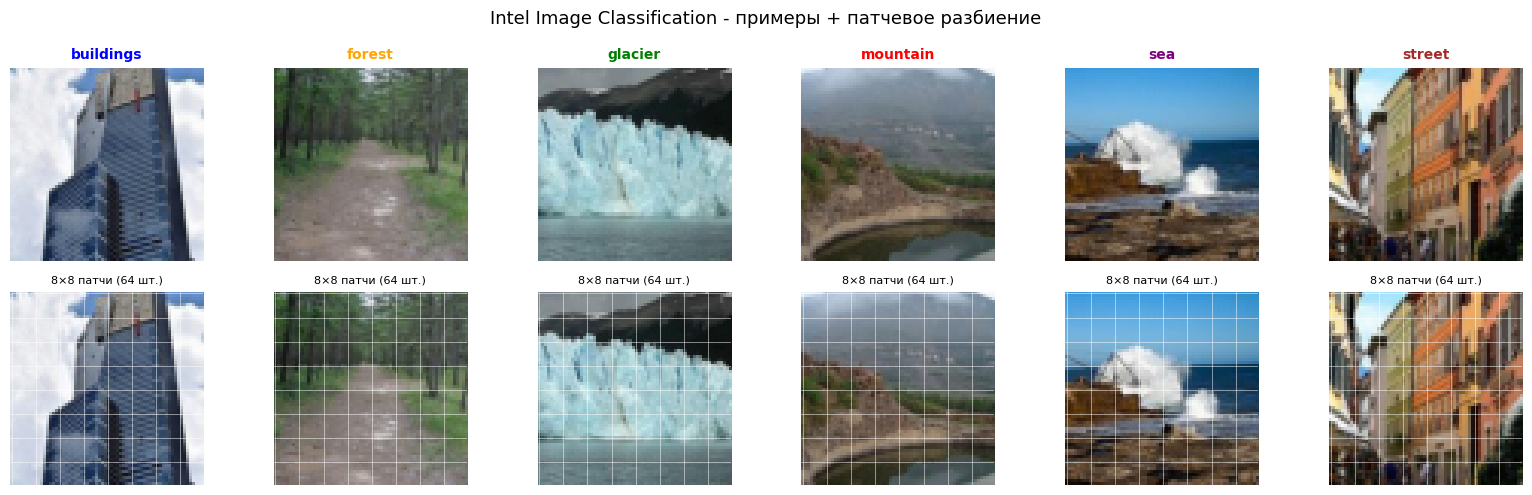

In [31]:
colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown']
fig, axes = plt.subplots(2, 6, figsize=(16, 5))
inv_norm = transforms.Normalize(
    mean=[-m/s for m, s in zip(mean, std)],
    std=[1/s for s in std]
)
for cls_idx, cls_name in enumerate(class_names_list):
    sample_idx = next(i for i, (_, l) in enumerate(test_ds) if l == cls_idx)
    img_t, _ = test_ds[sample_idx]
    img_show = inv_norm(img_t).permute(1, 2, 0).clip(0, 1).numpy()

    axes[0, cls_idx].imshow(img_show)
    axes[0, cls_idx].set_title(cls_name, fontsize=10, color=colors[cls_idx], fontweight="bold")
    axes[0, cls_idx].axis("off")
    axes[1, cls_idx].imshow(img_show)
    for px in range(0, img_size, patch_size):
        axes[1, cls_idx].axhline(px, color="white", lw=0.5, alpha=0.7)
        axes[1, cls_idx].axvline(px, color="white", lw=0.5, alpha=0.7)
    axes[1, cls_idx].axis("off")
    axes[1, cls_idx].set_title(f"8×8 патчи ({n_patches} шт.)", fontsize=8)

axes[0, 0].set_ylabel("Оригинал", fontsize=10)
axes[1, 0].set_ylabel("Патчи", fontsize=10)
plt.suptitle("Intel Image Classification - примеры + патчевое разбиение", fontsize=13)
plt.tight_layout()
plt.show()

## Инициализация Mamba модели

In [32]:
# Гиперпараметры модели
d_model = 128
num_layers = 4
d_state = 16

model = MambaClassifier(
    patch_dim=patch_dim,
    num_classes=n_classes,
    d_model=d_model,
    num_layers=num_layers,
    d_state=d_state
).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Параметров: {total_params:,}")
print(model)

Параметров: 314,886
MambaClassifier(
  (patch_embed): Sequential(
    (0): Linear(in_features=192, out_features=128, bias=True)
    (1): RMSNorm()
  )
  (mamba_layers): ModuleList(
    (0-3): 4 x MambaBlock(
      (in_proj): Linear(in_features=128, out_features=256, bias=True)
      (B_proj): Linear(in_features=128, out_features=16, bias=False)
      (C_proj): Linear(in_features=128, out_features=16, bias=False)
      (dt_proj): Linear(in_features=128, out_features=128, bias=True)
      (out_proj): Linear(in_features=128, out_features=128, bias=True)
      (norm): RMSNorm()
    )
  )
  (fc_out): Linear(in_features=128, out_features=6, bias=True)
)


## Обучение модели

Epoch 1/30:   0%|          | 0/220 [00:00<?, ?it/s]

[  1/30] train loss=1.1579 acc=0.536 | test loss=0.9834 acc=0.608


Epoch 2/30:   0%|          | 0/220 [00:00<?, ?it/s]

Epoch 3/30:   0%|          | 0/220 [00:00<?, ?it/s]

Epoch 4/30:   0%|          | 0/220 [00:00<?, ?it/s]

...

Epoch 27/30:   0%|          | 0/220 [00:00<?, ?it/s]

Epoch 28/30:   0%|          | 0/220 [00:00<?, ?it/s]

Epoch 29/30:   0%|          | 0/220 [00:00<?, ?it/s]

Epoch 30/30:   0%|          | 0/220 [00:00<?, ?it/s]

[ 30/30] train loss=0.2350 acc=0.915 | test loss=0.9128 acc=0.742
Лучшая точность на test: 0.763


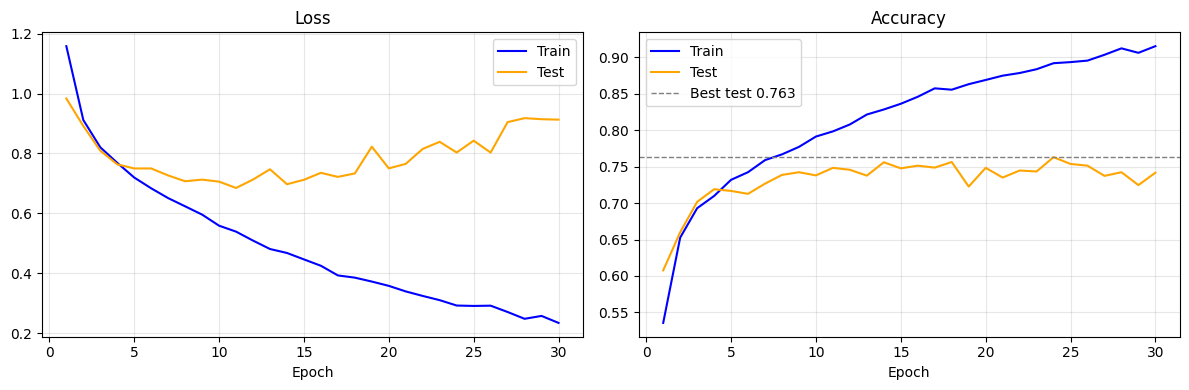

In [33]:
# Параметры обучения
epochs = 30
learning_rate = 3e-4

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
history = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}

def evaluate(loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            patches = img_to_patches(imgs)
            logits = model(patches)
            loss = criterion(logits, labels)
            total_loss += loss.item() * len(labels)
            correct += (logits.argmax(1) == labels).sum().item()
            total += len(labels)
    return total_loss / total, correct / total

best_test_acc = 0.0
for epoch in range(1, epochs + 1):
    model.train()
    train_loss, correct, total = 0.0, 0, 0
    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}", leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        patches = img_to_patches(imgs)
        
        optimizer.zero_grad()
        logits = model(patches)
        loss = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        train_loss += loss.item() * len(labels)
        correct += (logits.argmax(1) == labels).sum().item()
        total += len(labels)

    train_loss /= total
    train_acc = correct / total
    test_loss, test_acc = evaluate(test_loader)

    history["train_loss"].append(train_loss)
    history["test_loss"].append(test_loss)
    history["train_acc"].append(train_acc)
    history["test_acc"].append(test_acc)

    if test_acc > best_test_acc:
        best_test_acc = test_acc
        torch.save(model.state_dict(), "best_mamba_intel_hw6.pth")

    if epoch % 5 == 0 or epoch == 1:
        print(f"[{epoch:3d}/{epochs}] "
              f"train loss={train_loss:.4f} acc={train_acc:.3f} | "
              f"test loss={test_loss:.4f} acc={test_acc:.3f}")

print(f"Лучшая точность на test: {best_test_acc:.3f}")

# Графики обучения
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ep = range(1, epochs + 1)

axes[0].plot(ep, history["train_loss"], label="Train", color="blue")
axes[0].plot(ep, history["test_loss"], label="Test", color="orange")
axes[0].set_title("Loss", fontsize=12)
axes[0].set_xlabel("Epoch")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(ep, history["train_acc"], label="Train", color="blue")
axes[1].plot(ep, history["test_acc"], label="Test", color="orange")
axes[1].axhline(best_test_acc, color="gray", ls="--", lw=1, label=f"Best test {best_test_acc:.3f}")
axes[1].set_title("Accuracy", fontsize=12)
axes[1].set_xlabel("Epoch")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

## Анализ механизма выбора (Selection Mechanism) в Mamba

In [ ]:
# Загрузка лучшей модели
model.load_state_dict(torch.load("best_mamba_intel_hw6.pth", map_location=device))
model.eval()

# Функция для извлечения активаций из Mamba блоков
def get_selection_maps(cls_label, n=4):
    # Выборка изображений нужного класса из тестовой выборки
    imgs = torch.stack([test_ds[i][0] for i, (_, l) in enumerate(test_ds) if l == cls_label][:n]).to(device)
    patches = img_to_patches(imgs)
    
    selection_activations = []
    
    with torch.no_grad():
        x = model.patch_embed(patches)
        for layer_idx, mamba_layer in enumerate(model.mamba_layers):
            x_proj = mamba_layer.in_proj(x)
            x_main, _ = x_proj.chunk(2, dim=-1)
            x_main = mamba_layer.norm(x_main)
            dt = F.softplus(mamba_layer.dt_proj(x_main))
            
            # Метрика селективности: усредненный шаг времени (интенсивность обновления памяти)
            selection_score = dt.mean(dim=-1)
            selection_activations.append(selection_score.cpu().numpy())
            x = x + mamba_layer(x)
    
    return selection_activations

selection_by_class = []
for cls in range(n_classes):
    acts = get_selection_maps(cls)
    selection_by_class.append(acts)

print(f"Получены активации выбора для {n_classes} классов")
print(f"Количество слоев: {len(selection_by_class[0])}")
print(f"Форма активаций: {selection_by_class[0][0].shape}")

Получены активации выбора для 6 классов
Количество слоев: 4
Форма активаций: (4, 64)


## Визуализация карт селективности по слоям

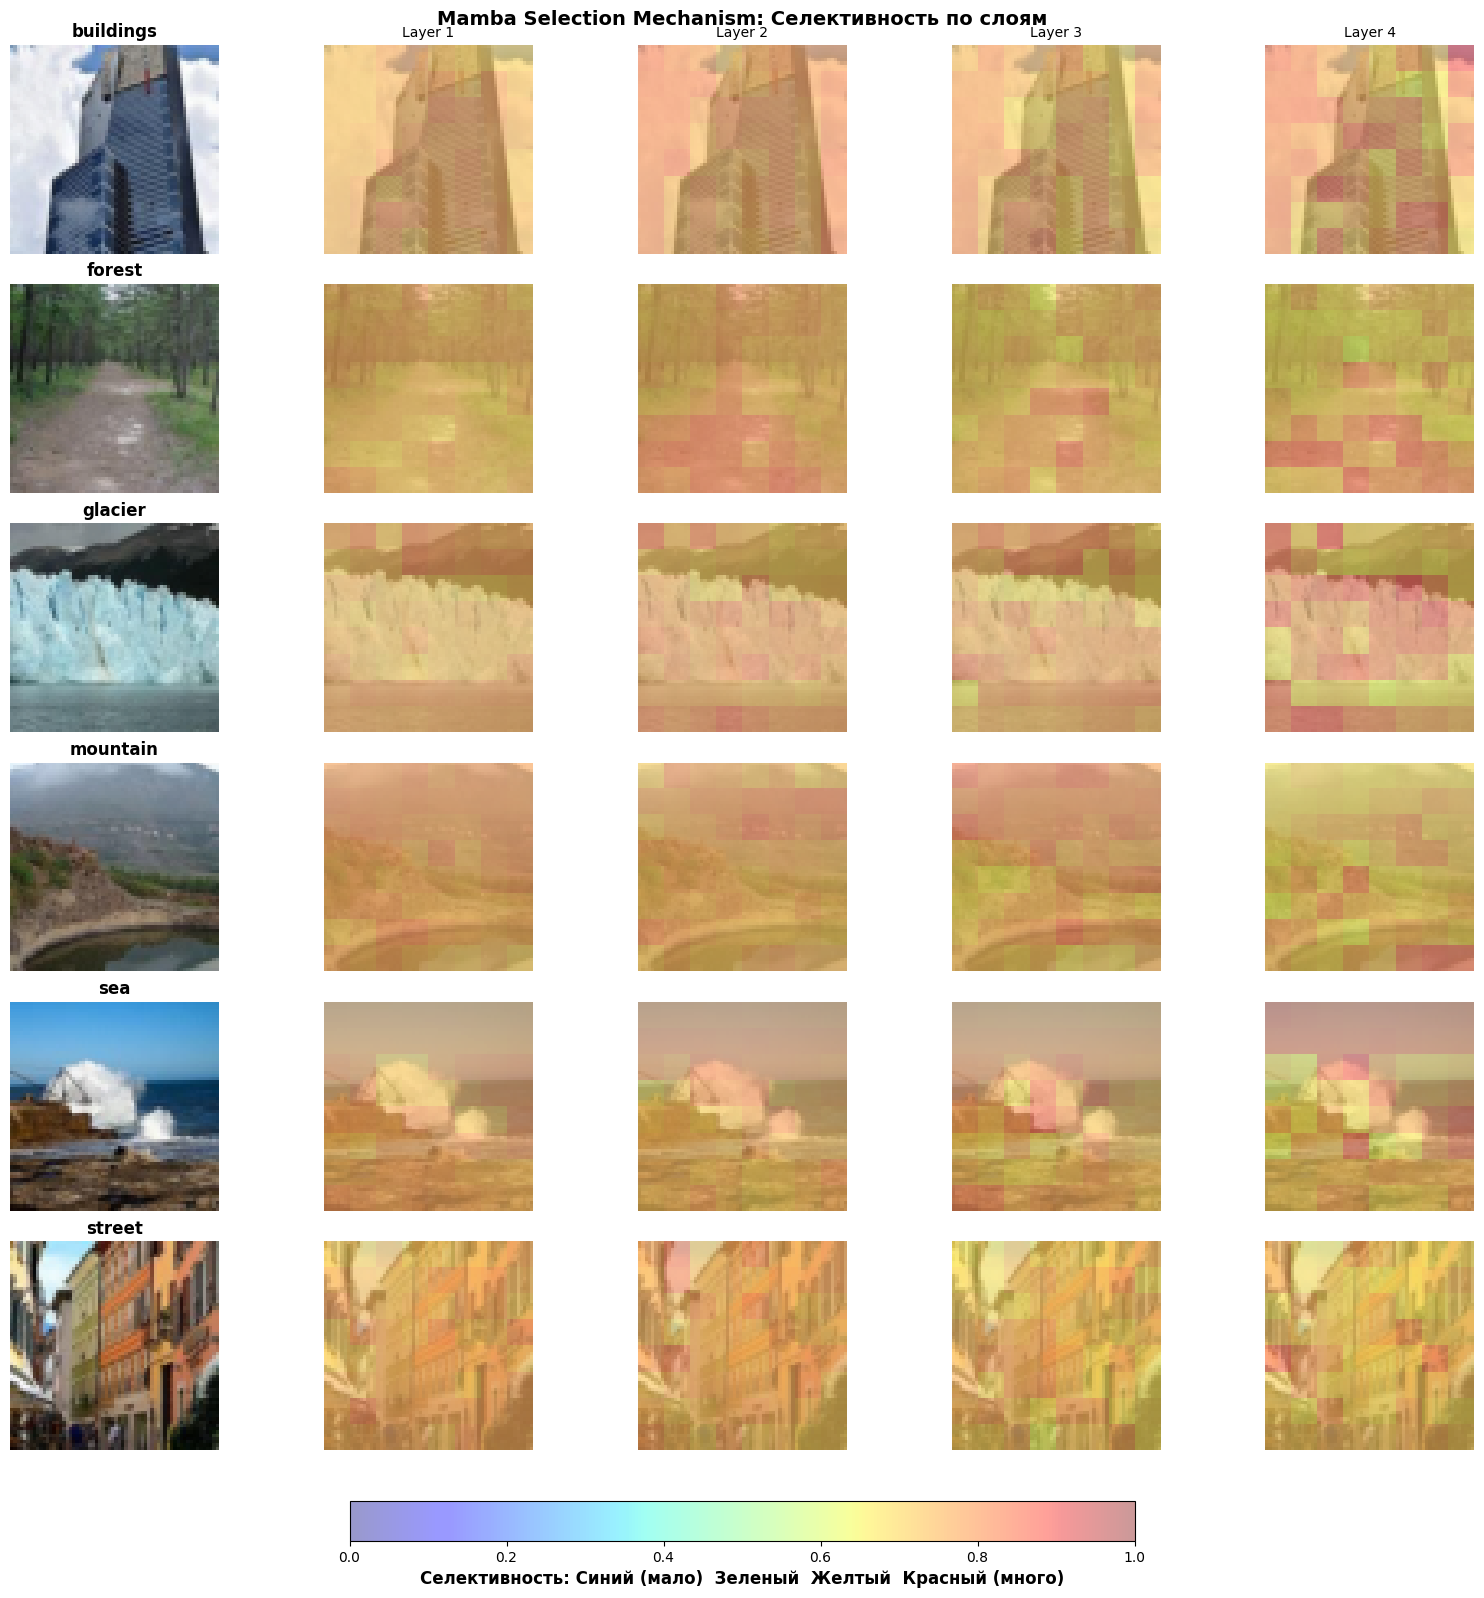

In [ ]:
# Визуализация карт селективности для каждого класса
fig, axes = plt.subplots(n_classes, num_layers + 1, figsize=(16, 3 * n_classes))
inv_norm = transforms.Normalize(
    mean=[-m/s for m, s in zip(mean, std)],
    std=[1/s for s in std]
)

for cls in range(n_classes):
    # Первый столбец: оригинальное изображение
    imgs = torch.stack([test_ds[i][0] for i, (_, l) in enumerate(test_ds) if l == cls][:1]).cpu()
    axes[cls, 0].imshow(inv_norm(imgs[0]).permute(1, 2, 0).clip(0, 1).numpy())
    axes[cls, 0].set_title(class_names_list[cls], fontsize=12, fontweight="bold")
    axes[cls, 0].axis('off')
    
    # Остальные столбцы: карты селективности из каждого слоя
    for layer_idx in range(num_layers):
        selection_map = selection_by_class[cls][layer_idx][0]
        selection_grid = selection_map.reshape(8, 8)
        
        ax = axes[cls, layer_idx + 1]
        img_np = inv_norm(imgs[0]).permute(1, 2, 0).clip(0, 1).numpy()
        ax.imshow(img_np, alpha=0.6)
        map_resized = np.kron(selection_grid, np.ones((img_size // 8, img_size // 8)))
        im = ax.imshow(map_resized, cmap='jet', alpha=0.4, vmin=0, vmax=1)
        ax.axis('off')
        if cls == 0:
            ax.set_title(f'Layer {layer_idx + 1}', fontsize=10)

plt.suptitle("Mamba Selection Mechanism", fontsize=14, fontweight='bold')
plt.tight_layout()

# Глобальная цветовая шкала
cbar = fig.colorbar(im, ax=axes.ravel().tolist(), orientation='horizontal', shrink=0.5, pad=0.03)
cbar.set_label('Селективность: Синий (мало)  Зеленый  Желтый  Красный (много)', fontsize=12, fontweight='bold')

plt.show()

## Анализ динамики селективности между слоями

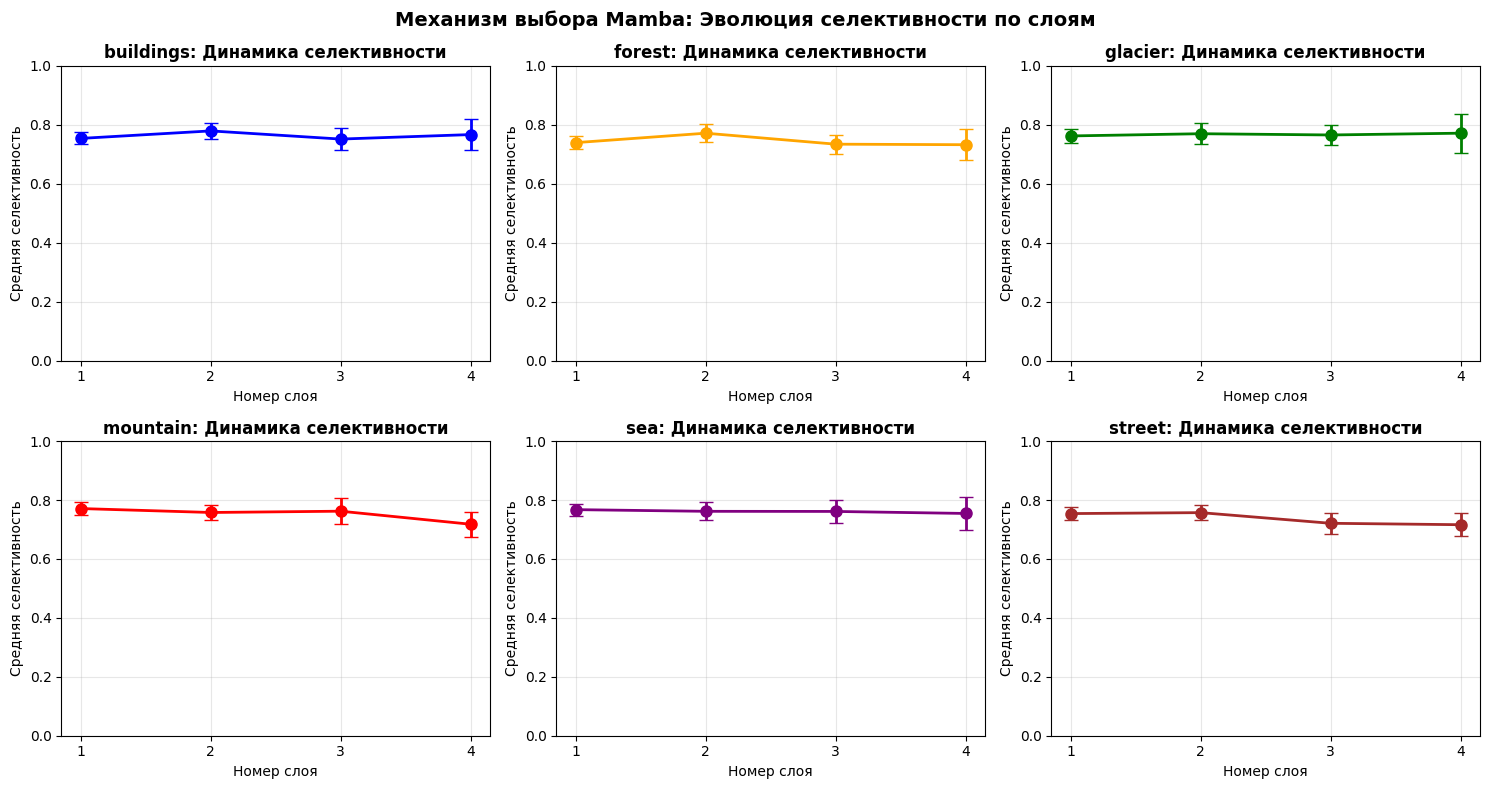

Селективность по классам

buildings:
Слой 1: mean=0.7539, std=0.0206, min=0.7124, max=0.7976
Слой 2: mean=0.7793, std=0.0259, min=0.7289, max=0.8251
Слой 3: mean=0.7516, std=0.0362, min=0.6878, max=0.8066
Слой 4: mean=0.7669, std=0.0519, min=0.6451, max=0.8922

forest:
Слой 1: mean=0.7395, std=0.0218, min=0.6901, max=0.7910
Слой 2: mean=0.7716, std=0.0299, min=0.7228, max=0.8370
Слой 3: mean=0.7343, std=0.0325, min=0.6591, max=0.8343
Слой 4: mean=0.7325, std=0.0525, min=0.6352, max=0.8447

glacier:
Слой 1: mean=0.7623, std=0.0231, min=0.7116, max=0.8092
Слой 2: mean=0.7698, std=0.0347, min=0.6994, max=0.8466
Слой 3: mean=0.7656, std=0.0353, min=0.6792, max=0.8303
Слой 4: mean=0.7716, std=0.0658, min=0.6515, max=0.8830

mountain:
Слой 1: mean=0.7711, std=0.0215, min=0.7159, max=0.8072
Слой 2: mean=0.7577, std=0.0262, min=0.7125, max=0.8246
Слой 3: mean=0.7621, std=0.0440, min=0.6605, max=0.8352
Слой 4: mean=0.7179, std=0.0430, min=0.6413, max=0.8554

sea:
Слой 1: mean=0.7674, std=0.0207

In [38]:
# Анализ динамики селективности
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for cls in range(n_classes):
    ax = axes[cls]
    
    # Для каждого слоя: среднее значение селективности
    layer_means = []
    layer_stds = []
    
    for layer_idx in range(num_layers):
        selection_map = selection_by_class[cls][layer_idx][0]
        layer_means.append(selection_map.mean())
        layer_stds.append(selection_map.std())
    
    ax.errorbar(range(1, num_layers + 1), layer_means, yerr=layer_stds, 
                fmt='o-', linewidth=2, markersize=8, capsize=5, color=colors[cls], label=class_names_list[cls])
    
    ax.set_title(f"{class_names_list[cls]}: Динамика селективности", fontweight='bold')
    ax.set_xlabel("Номер слоя")
    ax.set_ylabel("Средняя селективность")
    ax.set_xticks(range(1, num_layers + 1))
    ax.grid(alpha=0.3)
    ax.set_ylim([0, 1])

plt.suptitle("Мexанизм выбора Mamba: Эволюция селективности по слоям", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Статистика селективности
print("Селективность по классам")
for cls in range(n_classes):
    print(f"\n{class_names_list[cls]}:")
    for layer_idx in range(num_layers):
        selection_map = selection_by_class[cls][layer_idx][0]
        print(f"Слой {layer_idx + 1}: mean={selection_map.mean():.4f}, std={selection_map.std():.4f}, "
              f"min={selection_map.min():.4f}, max={selection_map.max():.4f}")

## Выводы и сравнение Mamba с Трансформером

### 1. Обучение и производительность Mamba
* **Точность:** Модель Mamba достигла 76.3% точности на тестовых данных.
* **Сравнение с трансформером:** Трансформер показал 81.9% точности, в то время как базовая реализация Mamba демонстрирует достойный результат. 
* **Переобучение:** На графиках функции потерь отчетливо видно переобучение моделей на малых данных после 10-15 эпох. Train Loss стабильно падает почти до 0.2, а Test Loss начинает расти после 12-й эпохи.

### 2. Анализ селективности по слоям
* **Среднее значение $dt$:** В среднем по всем слоям оно держится на одном уровне (~0.75-0.78). Это значит, что модель на всех этапах активно считывает информацию с картинки.
* **Концентрация внимания:** На первых слоях модель "смотрит" на изображение целиком (равномерный фон на тепловых картах). А вот на последних слоях она уже целенаправленно выделяет только самые важные детали (контуры зданий, гор), игнорируя ненужный фон.

### 3. Ключевые выводы
1. **Модель работает:** Архитектура Mamba успешно с картинками. Механизм выбора научился находить полезные визуальные признаки.
2. **Понятность решений:** Параметр $dt$ наглядно показывает, какие части картинки модель считает значимыми.
3. **Нехватка данных:** Mamba, как и трансформеры, склонна к быстрому переобучению на небольших датасетах. Чтобы улучшить результат, нужно больше картинок или более сильные аугментации.